# IY028 - SimCLR ROC-AUC NEW Dataset

This notebook repeats the SimCLR + SVM ROC-AUC test on `EXP-25-IY008/4_transformed_exp_time_series_NEW`.

The `_NEW` folder contains broad TF/group files, so the notebook discovers paired mCherry/GFP files, normalises TF names to uppercase, selects the top TF classes by paired-cell count, balances them, encodes each channel with the best SimCLR checkpoint, and fits a probability-enabled RBF SVM for one-vs-rest multiclass ROC curves.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm


def find_project_root(start=None):
    """Find the repository root from either the repo or experiment directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not find stochastic_simulations project root.")


PROJECT_ROOT = find_project_root()
EXP_DIR = PROJECT_ROOT / "experiments"
IY028_DIR = EXP_DIR / "EXP-26-IY028"
DATA_DIR = EXP_DIR / "EXP-25-IY008" / "4_transformed_exp_time_series_NEW"
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR.resolve()))

from models.ssl_transformer import SSL_Transformer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
META_COLS = ["id", "group", "experiment"]
MIN_CELLS_PER_CLASS = 50
MAX_CLASSES = 12
BEST_SIMCLR_CKPT = EXP_DIR / "EXP-26-IY024" / "IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()} -> {DATA_DIR}")
print(f"Checkpoint exists: {BEST_SIMCLR_CKPT.exists()} -> {BEST_SIMCLR_CKPT.name}")
print(f"Device: {DEVICE}")

Project root: /home/ianyang/stochastic_simulations
Data dir exists: True -> /home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series_NEW
Checkpoint exists: True -> IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth
Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load, Filter, Balance, and Split

In [2]:
def normalise_tf_name(group_name):
    """Remove channel prefixes and normalise TF names for cross-experiment grouping."""
    return re.sub(r"^ch\d+_", "", str(group_name)).upper()


def discover_paired_files(data_dir):
    """Find file stems that have both mCherry and GFP time-series CSVs."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Missing data directory: {data_dir}")
    gfp = {p.stem.replace("_GFP_time_series", ""): p for p in data_dir.glob("*_GFP_time_series.csv")}
    mcherry = {p.stem.replace("_mCherry_time_series", ""): p for p in data_dir.glob("*_mCherry_time_series.csv")}
    paired_keys = sorted(set(gfp) & set(mcherry))
    rows = []
    for key in paired_keys:
        experiment = key.split("_group_")[0]
        group = key.split("_group_", 1)[1]
        rows.append({
            "key": key,
            "experiment": experiment,
            "group": group,
            "tf": normalise_tf_name(group),
            "mcherry_path": mcherry[key],
            "gfp_path": gfp[key],
            "n_rows": sum(1 for _ in open(mcherry[key])) - 1,
        })
    return pd.DataFrame(rows)


def load_selected_pairs(pair_table, selected_classes):
    """Load all paired cells for selected TF classes."""
    m_arrays, g_arrays, metadata_rows = [], [], []
    selected_table = pair_table[pair_table["tf"].isin(selected_classes)].copy()
    for _, row in selected_table.iterrows():
        df_m = pd.read_csv(row["mcherry_path"])
        df_g = pd.read_csv(row["gfp_path"])
        time_cols_m = [c for c in df_m.columns if c not in META_COLS]
        time_cols_g = [c for c in df_g.columns if c not in META_COLS]
        # Keep only cells observed in both channels so paired rows stay aligned.
        common_ids = sorted(set(df_m["id"]) & set(df_g["id"]))
        df_m = df_m[df_m["id"].isin(common_ids)].set_index("id").loc[common_ids]
        df_g = df_g[df_g["id"].isin(common_ids)].set_index("id").loc[common_ids]
        m_arrays.append(df_m[time_cols_m].to_numpy(float))
        g_arrays.append(df_g[time_cols_g].to_numpy(float))
        for cell_id in common_ids:
            metadata_rows.append({
                "cell_id": cell_id,
                "class_name": row["tf"],
                "tf": row["tf"],
                "group": row["group"],
                "experiment": row["experiment"],
                "source_key": row["key"],
            })
    # Truncate each channel to its own common length before stacking experiments.
    min_tp_m = min(arr.shape[1] for arr in m_arrays)
    min_tp_g = min(arr.shape[1] for arr in g_arrays)
    X_m = np.vstack([arr[:, :min_tp_m] for arr in m_arrays])
    X_g = np.vstack([arr[:, :min_tp_g] for arr in g_arrays])
    metadata = pd.DataFrame(metadata_rows)
    class_to_label = {name: idx for idx, name in enumerate(selected_classes)}
    metadata["label"] = metadata["class_name"].map(class_to_label).astype(int)
    return X_m, X_g, metadata, class_to_label


def fill_nans(X, random_state=42):
    """Impute missing cell-trace values with a deterministic IterativeImputer."""
    X_arr = np.asarray(X, dtype=float)
    original_shape = X_arr.shape
    X_filled = np.atleast_2d(X_arr).copy()
    if not np.isnan(X_filled).any():
        return X_filled.reshape(original_shape)

    # IterativeImputer cannot infer a timepoint if every cell is missing there.
    all_nan_cols = np.isnan(X_filled).all(axis=0)
    if all_nan_cols.any():
        finite_values = X_filled[np.isfinite(X_filled)]
        fill_value = float(np.nanmean(finite_values)) if finite_values.size else 0.0
        X_filled[:, all_nan_cols] = fill_value

    imputer = IterativeImputer(
        max_iter=10,
        tol=1e-3,
        initial_strategy="mean",
        random_state=random_state,
    )
    X_imputed = imputer.fit_transform(X_filled)

    if np.isnan(X_imputed).any():
        col_medians = np.nanmedian(X_imputed, axis=0)
        global_median = float(np.nanmedian(X_imputed)) if np.isfinite(X_imputed).any() else 0.0
        col_medians = np.where(np.isfinite(col_medians), col_medians, global_median)
        nan_mask = np.isnan(X_imputed)
        X_imputed[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

    return X_imputed.reshape(original_shape)

def balance_by_label(X_m, X_g, metadata, random_state=42):
    """Subsample every class to the minority class size."""
    rng = np.random.default_rng(random_state)
    labels = metadata["label"].to_numpy()
    min_count = min(np.sum(labels == label) for label in sorted(np.unique(labels)))
    keep_idx = np.concatenate([
        rng.choice(np.where(labels == label)[0], size=min_count, replace=False)
        for label in sorted(np.unique(labels))
    ])
    # Sort after random sampling to keep matrices and metadata in the same order.
    keep_idx = np.sort(keep_idx)
    return X_m[keep_idx], X_g[keep_idx], metadata.iloc[keep_idx].reset_index(drop=True)


def timepoint_zscore(X, mean=None, std=None):
    """Z-score each timepoint across cells; return transformed data and fitted stats."""
    if mean is None:
        mean = X.mean(axis=0, keepdims=True)
    if std is None:
        std = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mean) / std, mean, std


pair_table = discover_paired_files(DATA_DIR)
class_counts = pair_table.groupby("tf", as_index=False)["n_rows"].sum().rename(columns={"n_rows": "paired_cells"})
class_counts = class_counts.sort_values("paired_cells", ascending=False)
selected_classes = class_counts.loc[class_counts["paired_cells"] >= MIN_CELLS_PER_CLASS, "tf"].head(MAX_CLASSES).tolist()

X_m_raw, X_g_raw, metadata_raw, class_to_label = load_selected_pairs(pair_table, selected_classes)
LABEL_NAMES = {idx: name for name, idx in class_to_label.items()}
# Impute channels separately so the two fluorescence traces keep their own structure.
X_m_clean = fill_nans(X_m_raw)
X_g_clean = fill_nans(X_g_raw)
X_m_bal, X_g_bal, metadata = balance_by_label(X_m_clean, X_g_clean, metadata_raw, RANDOM_STATE)
y = metadata["label"].to_numpy()

# Split both channels and metadata in one call so all paired arrays share indices.
X_m_train_raw, X_m_test_raw, X_g_train_raw, X_g_test_raw, y_train, y_test, meta_train, meta_test = train_test_split(
    X_m_bal,
    X_g_bal,
    y,
    metadata,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_m_train, m_mean, m_std = timepoint_zscore(X_m_train_raw)
X_m_test, _, _ = timepoint_zscore(X_m_test_raw, m_mean, m_std)
X_g_train, g_mean, g_std = timepoint_zscore(X_g_train_raw)
X_g_test, _, _ = timepoint_zscore(X_g_test_raw, g_mean, g_std)

print(f"Selected classes ({len(selected_classes)}): {selected_classes}")
print(f"Balanced cells: {len(metadata)}")
print(f"Train/test: {len(y_train)} / {len(y_test)}")
display(metadata["class_name"].value_counts().rename_axis("class_name").reset_index(name="balanced_n"))

Selected classes (12): ['OPI1', 'MSN2', 'YOX1', 'TEA1', 'ROX1', 'SOK2', 'CUP9', 'SPT15', 'CBF1', 'STB5', 'CIN5', 'RSC3']
Balanced cells: 1272
Train/test: 1017 / 255


,class_name,balanced_n
0,YOX1,106
1,CUP9,106
2,CIN5,106
3,CBF1,106
4,OPI1,106
5,MSN2,106
6,ROX1,106
7,SPT15,106
8,RSC3,106
9,SOK2,106


## Encode with Best SimCLR and Fit Probability SVM

In [3]:
def parse_arch_from_name(name):
    """Infer SSL_Transformer architecture parameters encoded in checkpoint names."""
    # Checkpoint filenames encode the transformer width, heads, and depth.
    return {
        "input_size": 1,
        "d_model": int(re.search(r"_D(\d+)", name).group(1)),
        "nhead": int(re.search(r"_H(\d+)", name).group(1)),
        "num_layers": int(re.search(r"_L(\d+)", name).group(1)),
        "dropout": 0.01,
        "use_conv1d": False,
    }


def load_simclr_model(checkpoint_path, device):
    """Load a frozen SSL_Transformer from a `.pth` checkpoint."""
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing SimCLR checkpoint: {checkpoint_path}")
    model = SSL_Transformer(**parse_arch_from_name(checkpoint_path.name))
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    return model.to(device).eval()


def encode_channel(model, X, device, batch_size=256):
    """Encode one channel matrix with `model.backbone.encode`."""
    embeddings = []
    with torch.no_grad():
        for start in tqdm(range(0, len(X), batch_size), desc="SimCLR encode"):
            batch = torch.from_numpy(X[start:start + batch_size]).float().unsqueeze(-1).to(device)
            embeddings.append(model.backbone.encode(batch).cpu().numpy())
    return np.concatenate(embeddings, axis=0)


simclr_model = load_simclr_model(BEST_SIMCLR_CKPT, DEVICE)
Z_m_train = encode_channel(simclr_model, X_m_train, DEVICE)
Z_m_test = encode_channel(simclr_model, X_m_test, DEVICE)
Z_g_train = encode_channel(simclr_model, X_g_train, DEVICE)
Z_g_test = encode_channel(simclr_model, X_g_test, DEVICE)

Z_train = np.concatenate([Z_m_train, Z_g_train], axis=1)
Z_test = np.concatenate([Z_m_test, Z_g_test], axis=1)
scaler = StandardScaler()
Z_train_scaled = scaler.fit_transform(Z_train)
Z_test_scaled = scaler.transform(Z_test)

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=RANDOM_STATE,
)
svm.fit(Z_train_scaled, y_train)
y_score = svm.predict_proba(Z_test_scaled)
y_pred = svm.predict(Z_test_scaled)
print(f"SimCLR train embeddings: {Z_train_scaled.shape}")
print(f"SimCLR test embeddings : {Z_test_scaled.shape}")

SimCLR encode: 100%|██████████| 1/1 [00:00<00:00, 1084.08it/s]


SimCLR train embeddings: (1017, 32)
SimCLR test embeddings : (255, 32)


## Compute and Plot ROC-AUC

In [4]:
classes = np.array(sorted(LABEL_NAMES))
label_binarizer = LabelBinarizer()
label_binarizer.fit(classes)
y_test_bin = label_binarizer.transform(y_test)

roc_rows = []
fpr = {}
tpr = {}
roc_auc = {}
for class_index, class_label in enumerate(classes):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_bin[:, class_index], y_score[:, class_index])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])
    roc_rows.append({
        "class_label": class_label,
        "class_name": LABEL_NAMES[class_label],
        "auc_roc": roc_auc[class_label],
        "test_n": int(np.sum(y_test == class_label)),
    })

micro_auc = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
weighted_auc = roc_auc_score(y_test_bin, y_score, average="weighted", multi_class="ovr")
accuracy = float(np.mean(y_pred == y_test))

roc_summary = pd.DataFrame(roc_rows)
summary_rows = pd.DataFrame([
    {"class_label": "micro", "class_name": "micro-average", "auc_roc": micro_auc, "test_n": len(y_test)},
    {"class_label": "macro", "class_name": "macro-average", "auc_roc": macro_auc, "test_n": len(y_test)},
    {"class_label": "weighted", "class_name": "weighted-average", "auc_roc": weighted_auc, "test_n": len(y_test)},
])
roc_summary_all = pd.concat([roc_summary, summary_rows], ignore_index=True)

print(f"Held-out accuracy: {accuracy:.4f}")
print(f"Micro-average ROC-AUC: {micro_auc:.4f}")
print(f"Macro-average ROC-AUC: {macro_auc:.4f}")
print(f"Weighted-average ROC-AUC: {weighted_auc:.4f}")
display(roc_summary_all)

Held-out accuracy: 0.4549
Micro-average ROC-AUC: 0.8621
Macro-average ROC-AUC: 0.8473
Weighted-average ROC-AUC: 0.8480


,class_label,class_name,auc_roc,test_n
0,0,OPI1,0.699227,21
1,1,MSN2,0.987383,21
2,2,YOX1,0.909849,21
3,3,TEA1,0.906165,22
4,4,ROX1,0.695564,21
5,5,SOK2,0.809727,21
6,6,CUP9,0.928014,22
7,7,SPT15,0.875732,22
8,8,CBF1,0.801994,21
9,9,STB5,0.880138,21


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_simclr_roc_auc_NEW.png


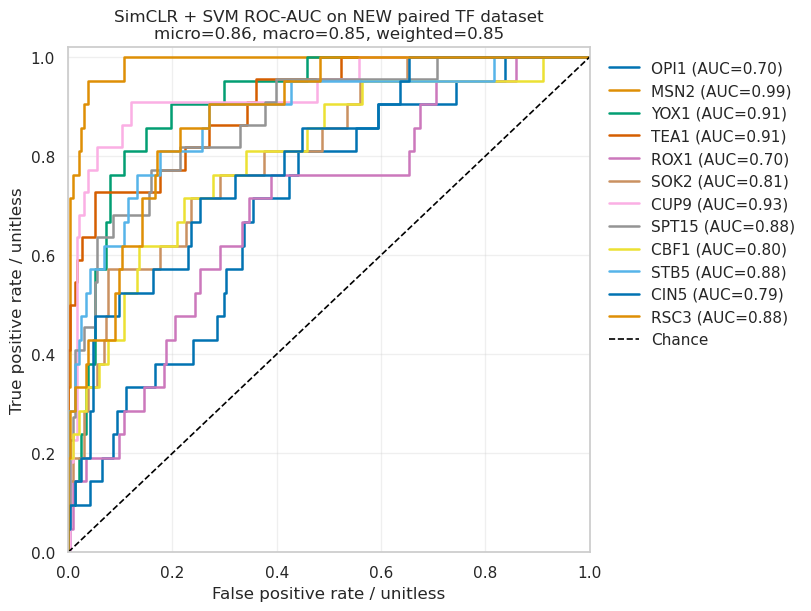

In [5]:
palette = sns.color_palette("colorblind", n_colors=len(classes))
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

for color, class_label in zip(palette, classes):
    ax.plot(
        fpr[class_label],
        tpr[class_label],
        color=color,
        linewidth=1.8,
        label=f"{LABEL_NAMES[class_label]} (AUC={roc_auc[class_label]:.2f})",
    )

ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1.2, label="Chance")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False positive rate / unitless")
ax.set_ylabel("True positive rate / unitless")
ax.set_title(
    "SimCLR + SVM ROC-AUC on NEW paired TF dataset\n"
    f"micro={micro_auc:.2f}, macro={macro_auc:.2f}, weighted={weighted_auc:.2f}"
)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
ax.grid(alpha=0.3)

fig_path = IY028_DIR / "IY028_simclr_roc_auc_NEW.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## Save ROC Metrics

In [6]:
metrics_path = IY028_DIR / "IY028_simclr_roc_auc_metrics_NEW.csv"
roc_summary_all.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_simclr_roc_auc_metrics_NEW.csv
